In [1]:
import pandas as pd
import numpy as np
from utils.mpip_parse import MPIPParser
from utils.parse_coscheduling_runs import CoSchedulingRunsParser
import matplotlib.pyplot as plt
from utils.parse_rate_limits import RateLimitParser

In [2]:
parser = CoSchedulingRunsParser()
data_isolated = parser.parse_isolated("../run_data/experiments_coscheduling_isolated/20260527_083005/data", progress=True)
data_coscheduled = parser.parse_coscheduled("../run_data/experiments_coscheduling_app_coscheduled/20260527_082956/data", progress=True)

Phase 1: Collecting files: 64it [00:00, 6743.76it/s]
Phase 2: Parsing files:   0%|          | 0/64 [00:00<?, ?it/s]

Phase 2: Parsing files: 100%|██████████| 64/64 [00:21<00:00,  3.01it/s]
Phase 1: Collecting files: 304it [00:00, 8586.32it/s]
Phase 2: Parsing files: 100%|██████████| 304/304 [03:47<00:00,  1.34it/s]


In [4]:
# Aggregate data_isolated by App and Num Nodes
# Group by App and Num Nodes, then calculate mean, median, std for each metric across Run Iterations
data_isolated_agg = data_isolated.groupby(['App', 'Num Nodes']).agg({
    'App Time Average': ['mean', 'median', 'std'],
    'MPI Time Average': ['mean', 'median', 'std'],
    'Total Messages Sent': ['mean', 'median', 'std'],
    'Total Bytes Sent': ['mean', 'median', 'std']
}).reset_index()

# Flatten column names
data_isolated_agg.columns = ['App', 'Num Nodes', 
                             'App Time Average Mean', 'App Time Average Median', 'App Time Average Std',
                             'MPI Time Average Mean', 'MPI Time Average Median', 'MPI Time Average Std',
                             'Total Messages Sent Mean', 'Total Messages Sent Median', 'Total Messages Sent Std',
                             'Total Bytes Sent Mean', 'Total Bytes Sent Median', 'Total Bytes Sent Std']

data_isolated_agg[data_isolated_agg["Num Nodes"] == 8]

# Aggregate data_coscheduled by App A, App B, and Num Nodes
# Group by App A, App B, and Num Nodes, then calculate mean, median, std for each metric across Run Iterations
data_coscheduled_agg = data_coscheduled.groupby(['App A', 'App B', 'Num Nodes']).agg({
    'App A Time Average': ['mean', 'median', 'std'],
    'App B Time Average': ['mean', 'median', 'std'],
    'App A MPI Time Average': ['mean', 'median', 'std'],
    'App B MPI Time Average': ['mean', 'median', 'std'],
    'App A Total Messages Sent': ['mean', 'median', 'std'],
    'App B Total Messages Sent': ['mean', 'median', 'std'],
    'App A Total Bytes Sent': ['mean', 'median', 'std'],
    'App B Total Bytes Sent': ['mean', 'median', 'std']
}).reset_index()

# Flatten column names
data_coscheduled_agg.columns = ['App A', 'App B', 'Num Nodes',
                                'App A Time Average Mean', 'App A Time Average Median', 'App A Time Average Std',
                                'App B Time Average Mean', 'App B Time Average Median', 'App B Time Average Std',
                                'App A MPI Time Average Mean', 'App A MPI Time Average Median', 'App A MPI Time Average Std',
                                'App B MPI Time Average Mean', 'App B MPI Time Average Median', 'App B MPI Time Average Std',
                                'App A Total Messages Sent Mean', 'App A Total Messages Sent Median', 'App A Total Messages Sent Std',
                                'App B Total Messages Sent Mean', 'App B Total Messages Sent Median', 'App B Total Messages Sent Std',
                                'App A Total Bytes Sent Mean', 'App A Total Bytes Sent Median', 'App A Total Bytes Sent Std',
                                'App B Total Bytes Sent Mean', 'App B Total Bytes Sent Median', 'App B Total Bytes Sent Std']

data_isolated.to_csv("../processed_data/data_isolated.csv")
data_isolated_agg.to_csv("../processed_data/data_isolated_agg.csv")

data_coscheduled.to_csv("../processed_data/data_coscheduled.csv")
data_coscheduled_agg.to_csv("../processed_data/data_coscheduled_agg.csv")

In [6]:
rate_limit_parser = RateLimitParser("../rate_limit_data/20260625_114931/data")
rate_limit_parser.parse()
rate_limits = rate_limit_parser.get_rate_limits()
bandwidths = rate_limit_parser.get_bandwidths()

In [7]:
rate_limits

,Rank A,Rank B,Rate Limit (messages/sec),Run Index
0,0,1,7651560.0,0
1,0,2,5711840.0,0
2,0,3,5673710.0,0
3,0,4,6669250.0,0
4,0,5,6617080.0,0
...,...,...,...,...
555,7,2,3923370.0,9
556,7,3,3922580.0,9
557,7,4,5017810.0,9
558,7,5,3981720.0,9


In [8]:
bandwidths

,Rank A,Rank B,Bandwidth (MB/s),Run Index
0,0,1,24811.26,0
1,0,2,22670.20,0
2,0,3,22474.78,0
3,0,4,14070.80,0
4,0,5,14171.33,0
...,...,...,...,...
555,7,2,10297.39,9
556,7,3,9966.91,9
557,7,4,22344.90,9
558,7,5,22406.57,9


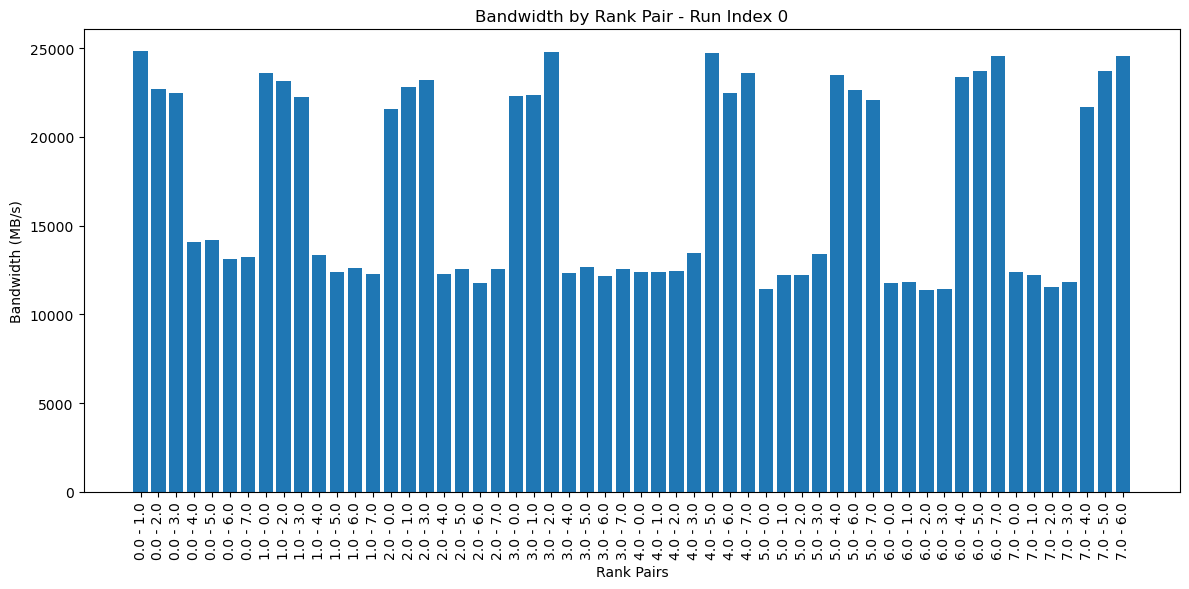

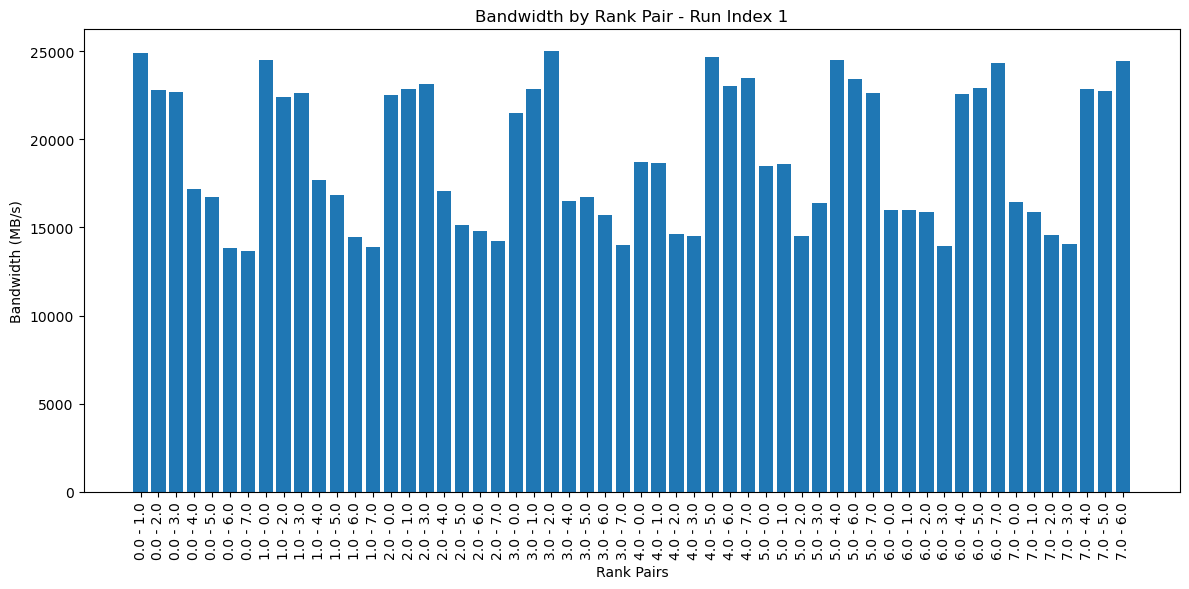

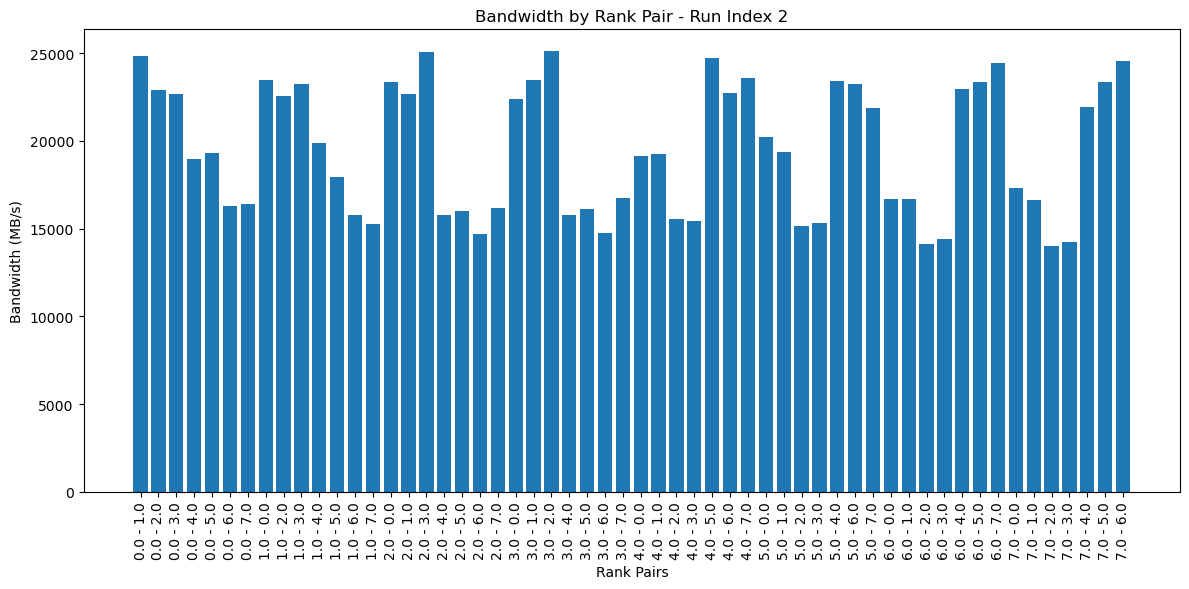

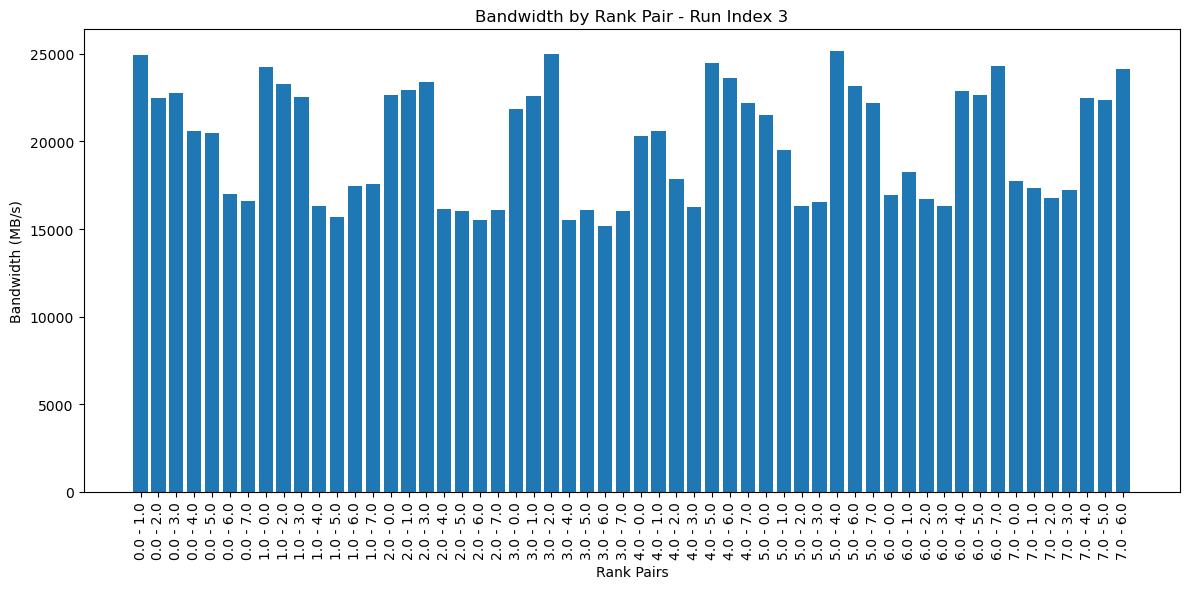

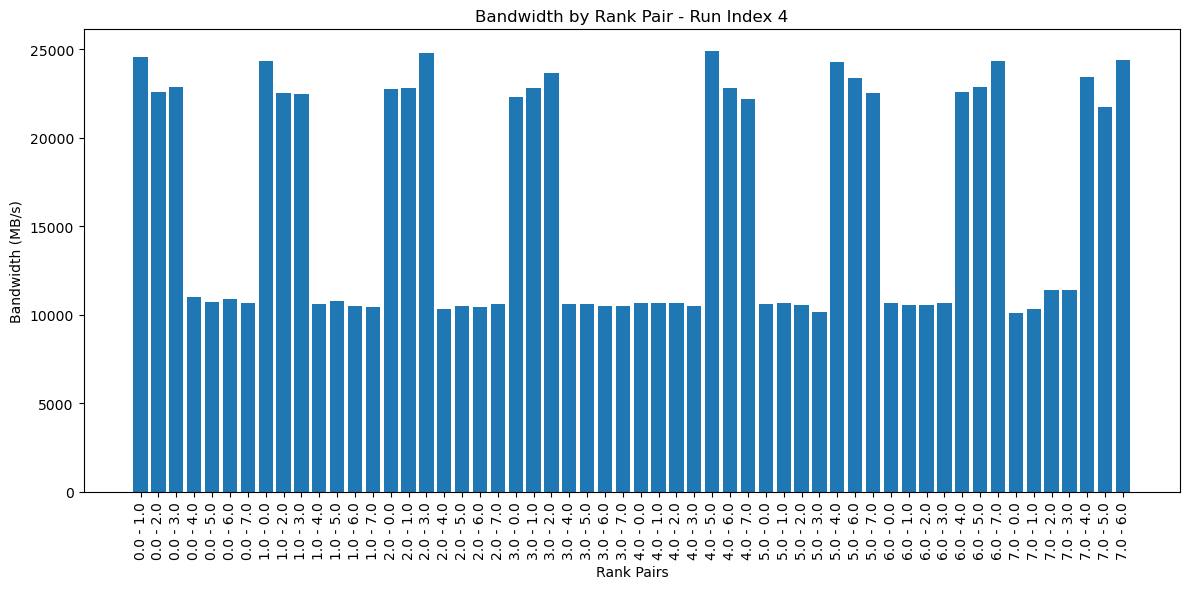

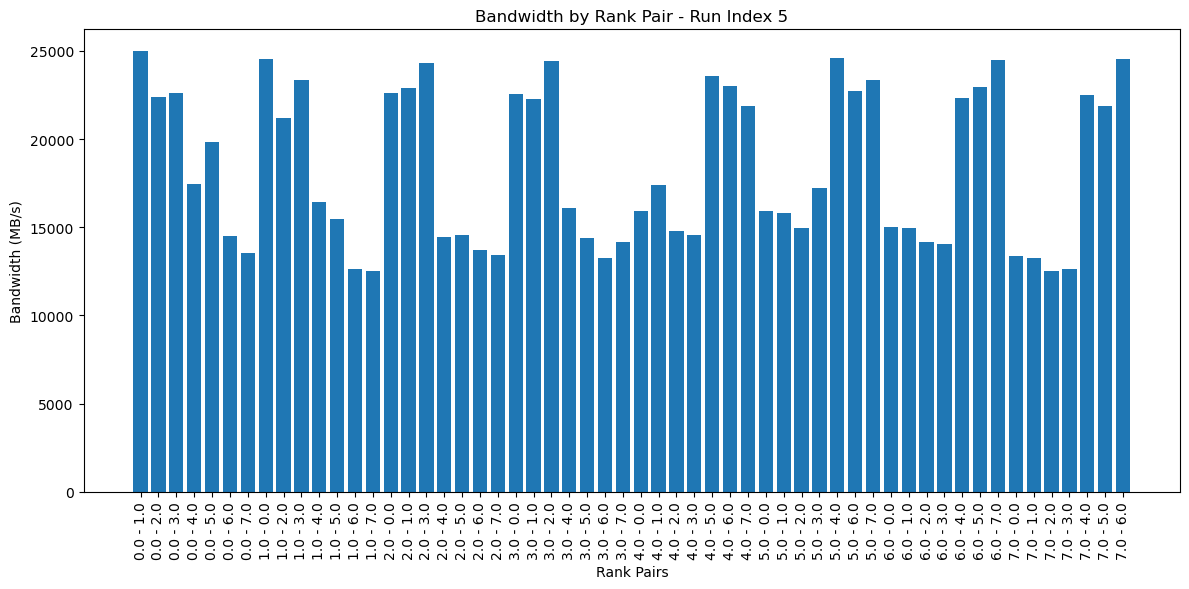

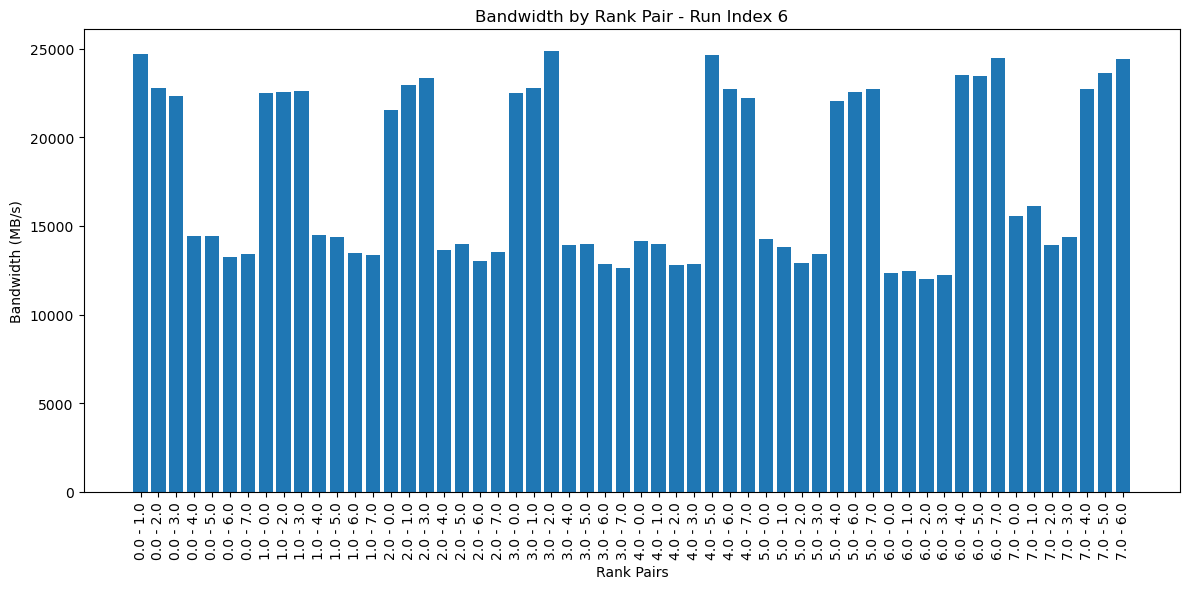

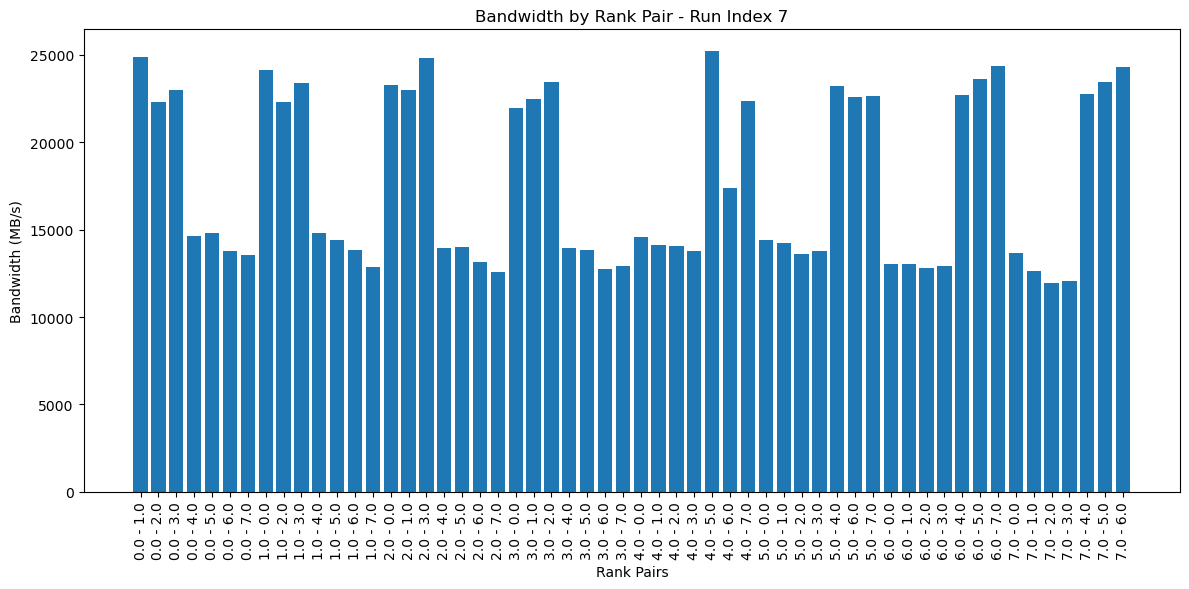

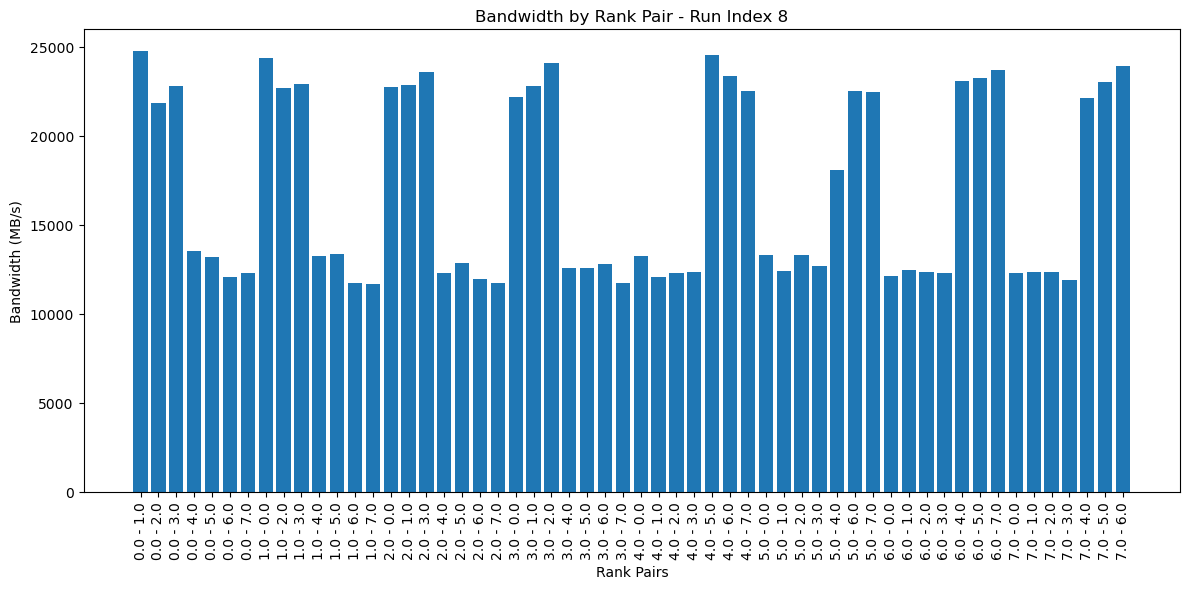

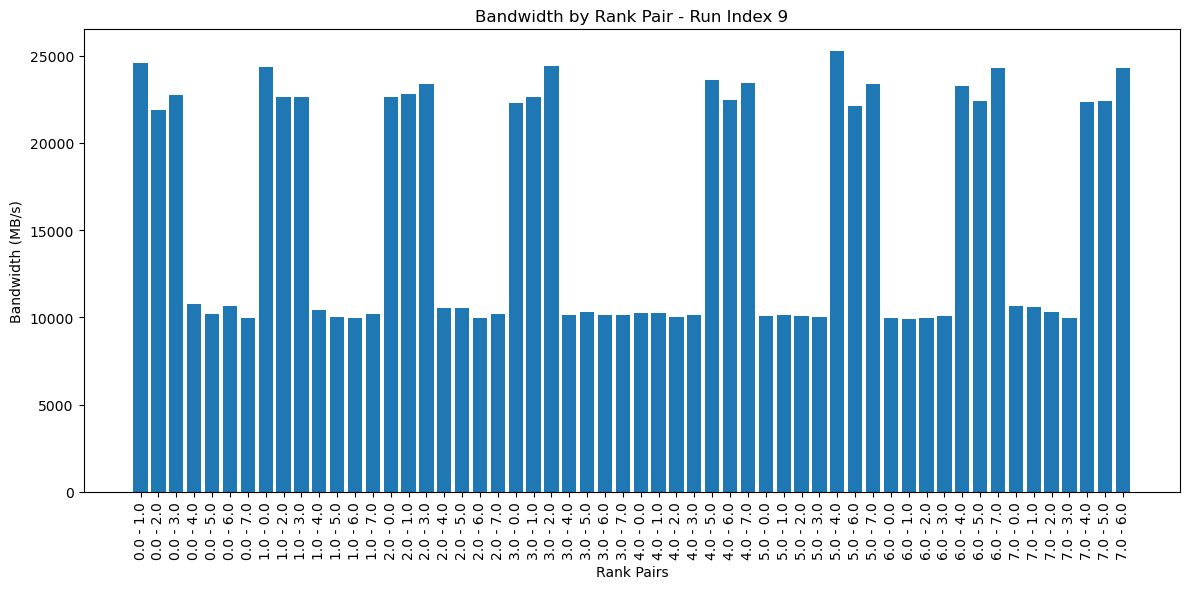

In [9]:
for run_index in bandwidths['Run Index'].unique():
    df_run = bandwidths[bandwidths['Run Index'] == run_index]
    
    plt.figure(figsize=(12, 6))
    x_labels = [f"{row['Rank A']} - {row['Rank B']}" for _, row in df_run.iterrows()]
    y_values = df_run['Bandwidth (MB/s)'].values
    
    plt.bar(range(len(x_labels)), y_values)
    plt.xticks(range(len(x_labels)), x_labels, rotation=90)
    plt.xlabel("Rank Pairs")
    plt.ylabel("Bandwidth (MB/s)")
    plt.title(f"Bandwidth by Rank Pair - Run Index {run_index}")
    plt.tight_layout()
    plt.show()

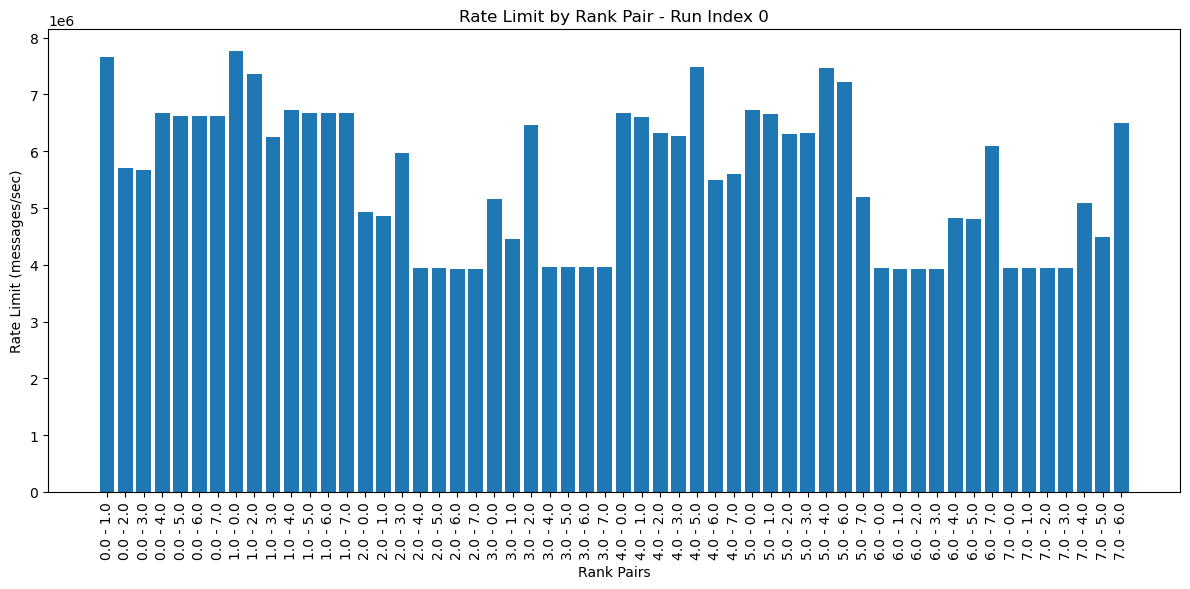

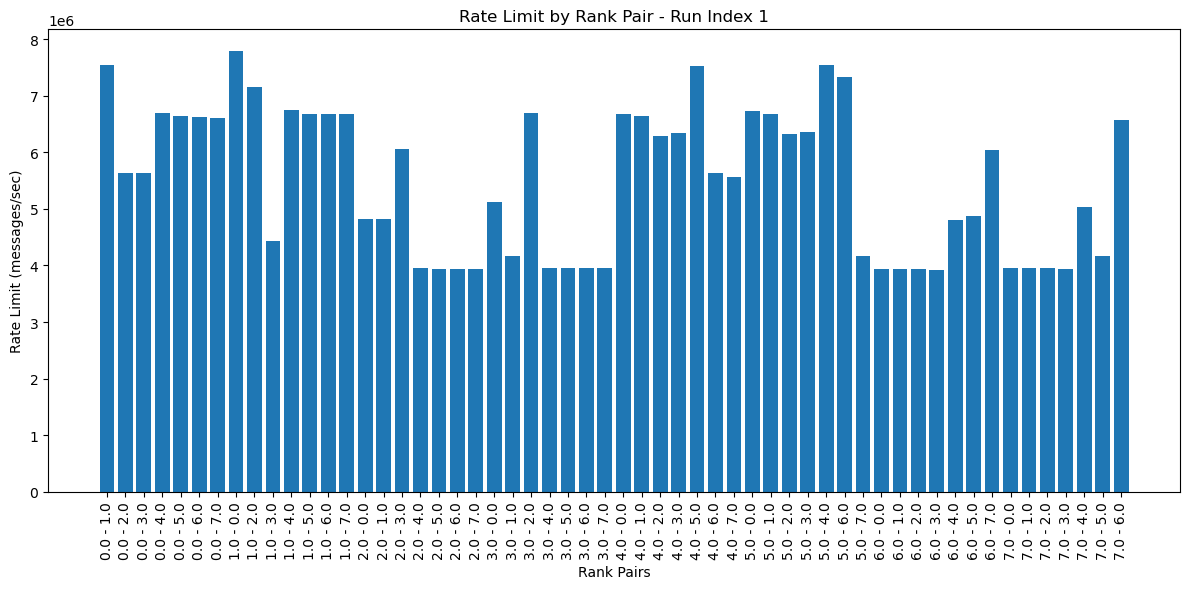

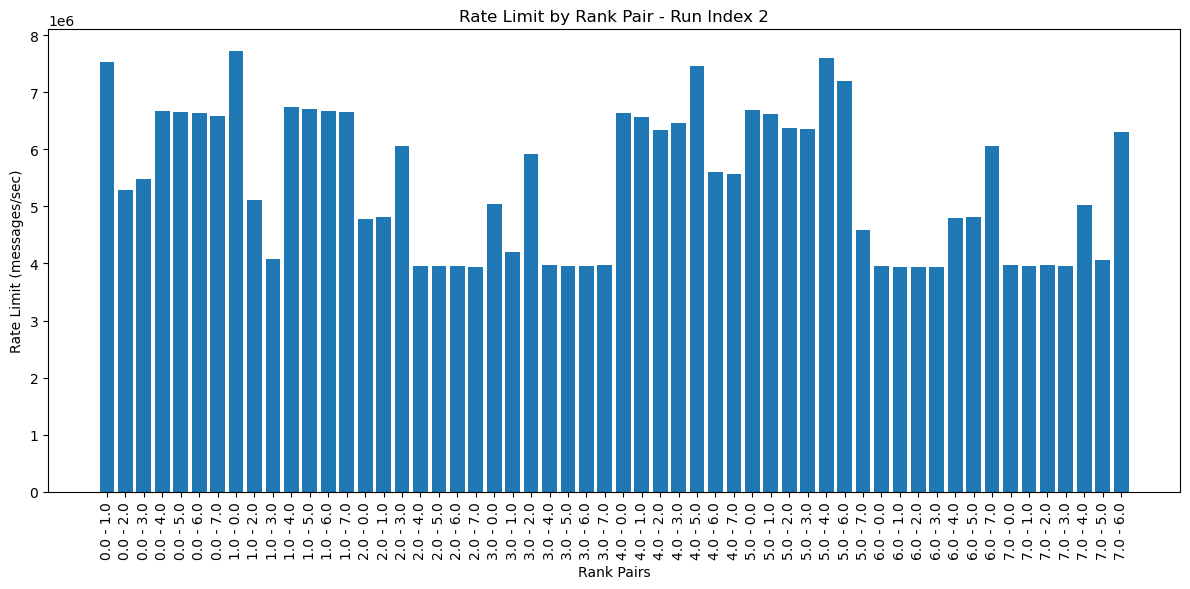

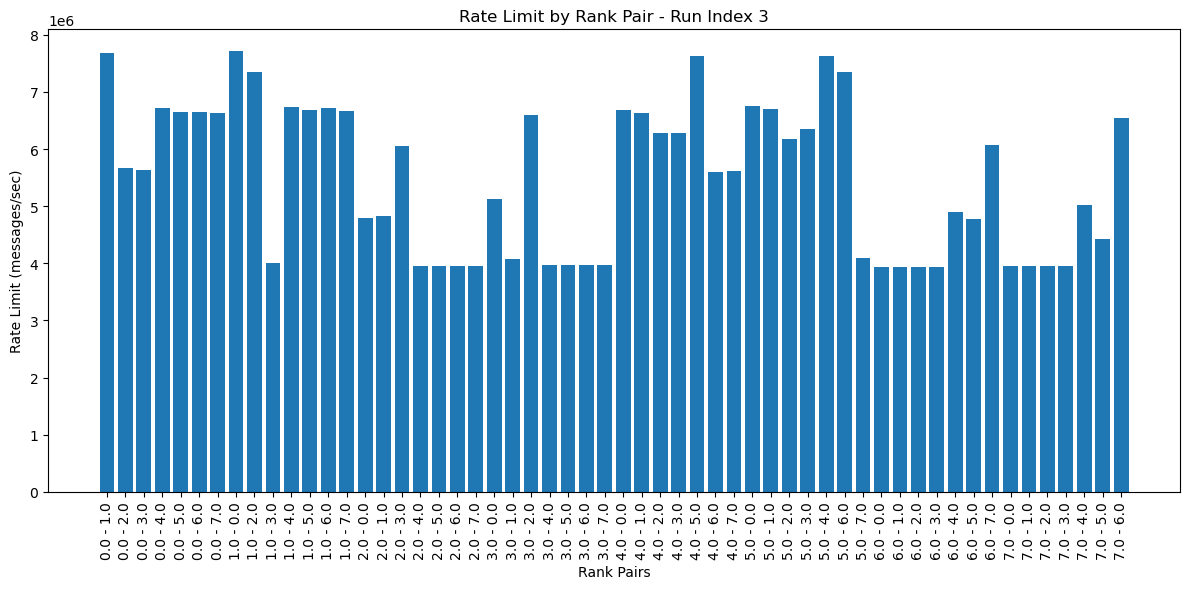

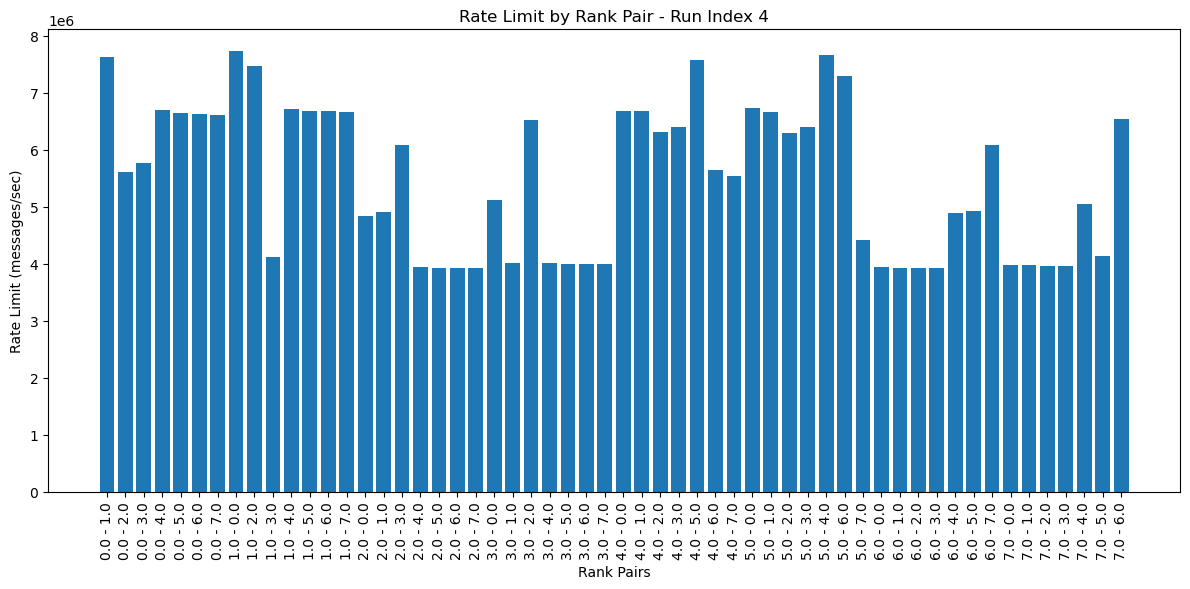

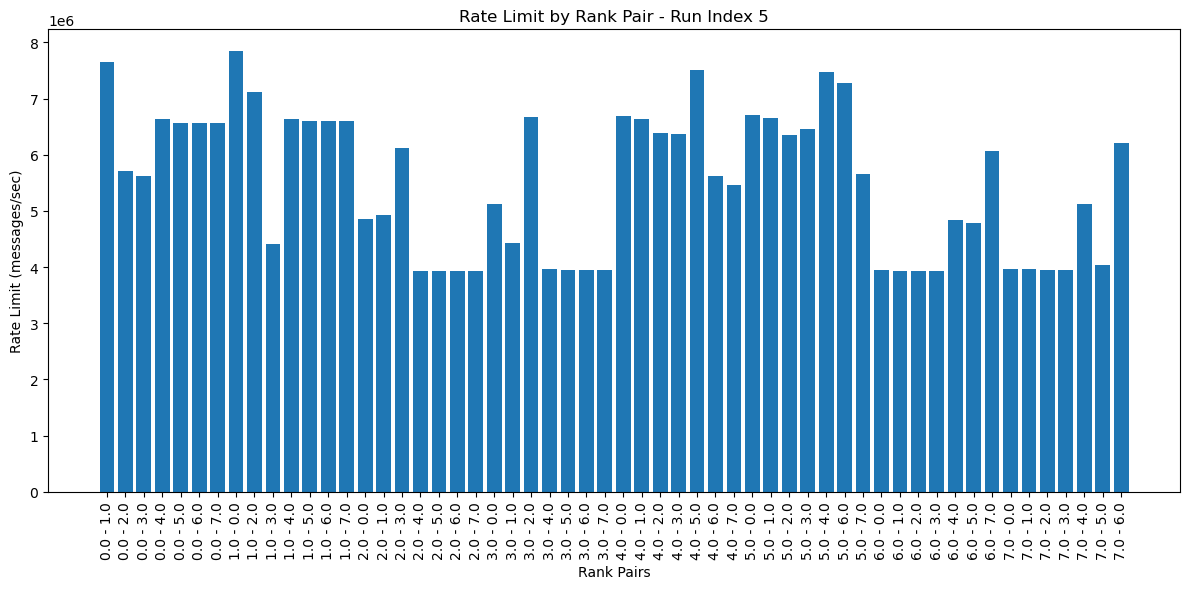

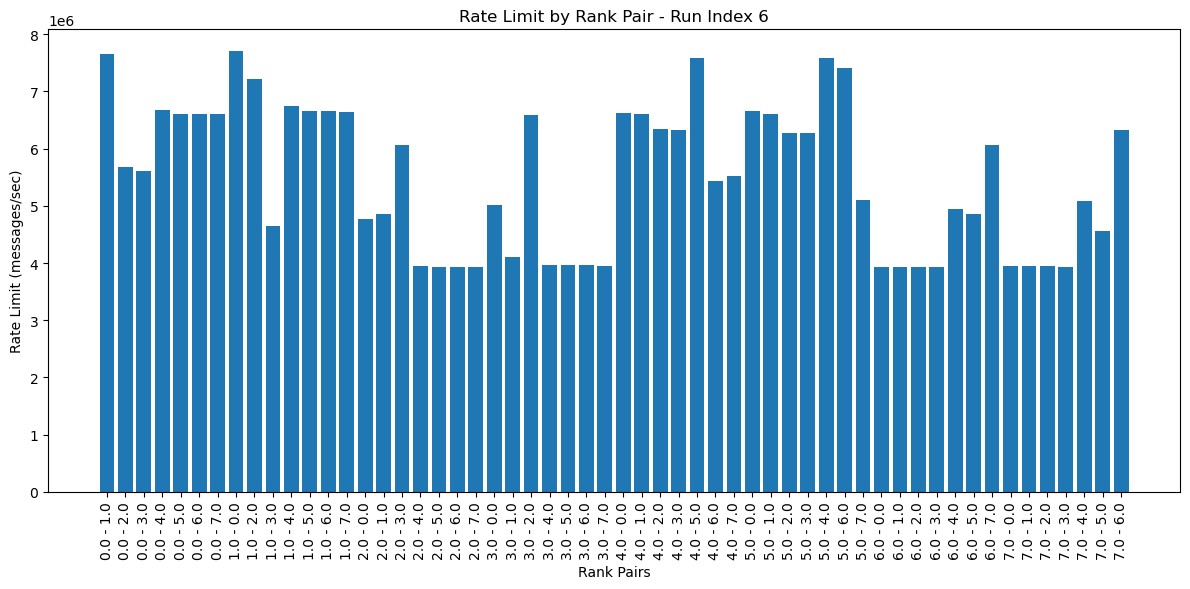

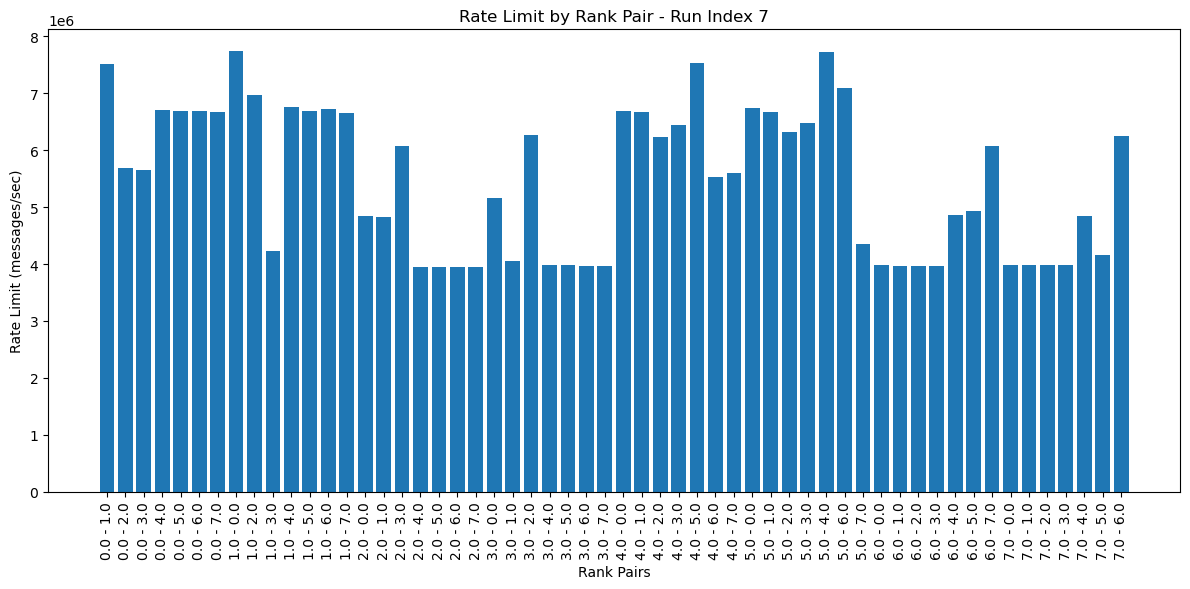

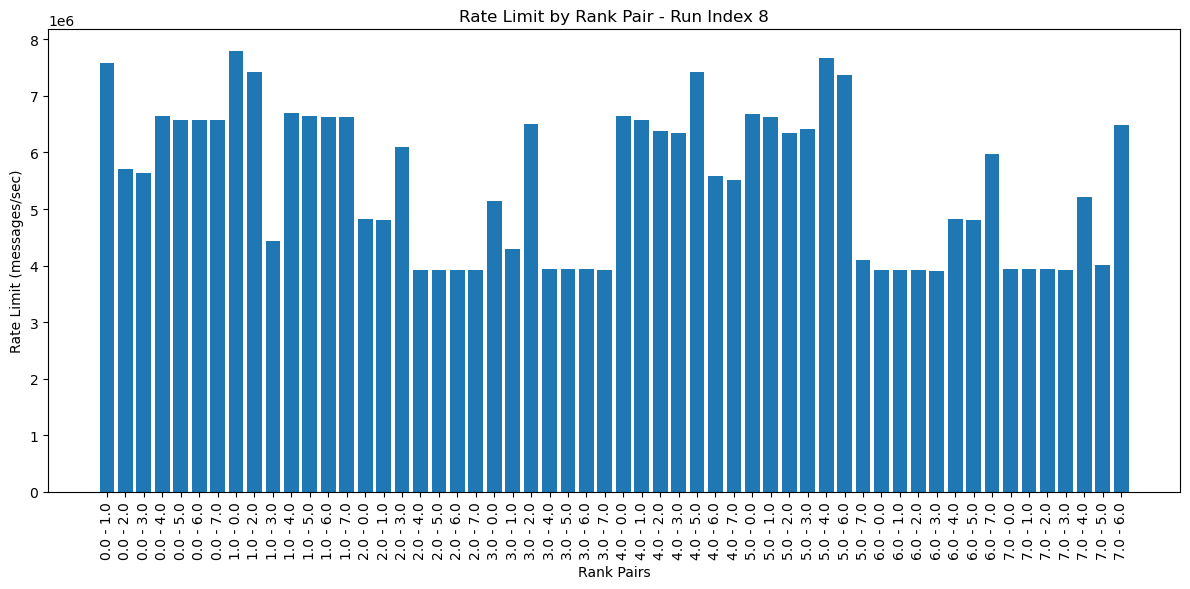

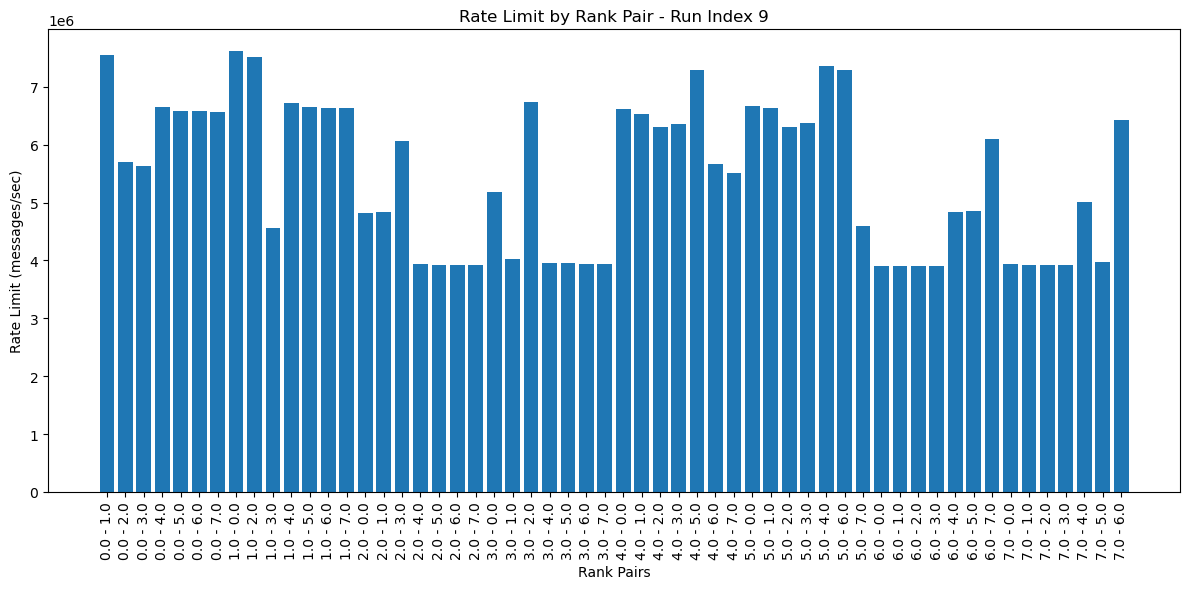

In [10]:
for run_index in rate_limits['Run Index'].unique():
    df_run = rate_limits[rate_limits['Run Index'] == run_index]
    
    plt.figure(figsize=(12, 6))
    x_labels = [f"{row['Rank A']} - {row['Rank B']}" for _, row in df_run.iterrows()]
    y_values = df_run['Rate Limit (messages/sec)'].values
    
    plt.bar(range(len(x_labels)), y_values)
    plt.xticks(range(len(x_labels)), x_labels, rotation=90)
    plt.xlabel("Rank Pairs")
    plt.ylabel("Rate Limit (messages/sec)")
    plt.title(f"Rate Limit by Rank Pair - Run Index {run_index}")
    plt.tight_layout()
    plt.show()

In [11]:
data_isolated_agg[(data_isolated_agg["App"] == "beatnik") & (data_isolated_agg["Num Nodes"] == 8)]

,App,Num Nodes,App Time Average Mean,App Time Average Median,App Time Average Std,MPI Time Average Mean,MPI Time Average Median,MPI Time Average Std,Total Messages Sent Mean,Total Messages Sent Median,Total Messages Sent Std,Total Bytes Sent Mean,Total Bytes Sent Median,Total Bytes Sent Std
2,beatnik,8,397.734375,396.977679,4.860808,99.906362,98.491295,3.282818,19996182.0,19996182.0,0.0,1.092655e+13,1.092655e+13,0.0


In [12]:
data_coscheduled_agg[(data_coscheduled_agg["App A"] == "beatnik") & (data_coscheduled_agg["App B"] == "beatnik") & (data_coscheduled_agg["Num Nodes"] == 8)]

,App A,App B,Num Nodes,App A Time Average Mean,App A Time Average Median,App A Time Average Std,App B Time Average Mean,App B Time Average Median,App B Time Average Std,App A MPI Time Average Mean,...,App A Total Messages Sent Std,App B Total Messages Sent Mean,App B Total Messages Sent Median,App B Total Messages Sent Std,App A Total Bytes Sent Mean,App A Total Bytes Sent Median,App A Total Bytes Sent Std,App B Total Bytes Sent Mean,App B Total Bytes Sent Median,App B Total Bytes Sent Std
6,beatnik,beatnik,8,449.412388,450.0,18.7263,448.563616,449.127232,19.149793,158.868862,...,0.0,19996182.0,19996182.0,0.0,1.092655e+13,1.092655e+13,0.0,0.0,0.0,0.0


In [13]:
# App profiles
app_profiles = {}
for app in data_isolated_agg["App"].unique():
    filtered_data_isolated_agg = data_isolated_agg[(data_isolated_agg["App"] == app) & (data_isolated_agg["Num Nodes"] == 8)]
    app_profiles[app] = {}
    app_profiles[app]["App Time"] = filtered_data_isolated_agg["App Time Average Mean"].mean()
    app_profiles[app]["MPI Time"] = filtered_data_isolated_agg["MPI Time Average Mean"].mean()
    app_profiles[app]["Total Bytes"] = filtered_data_isolated_agg["Total Bytes Sent Mean"].mean()
    app_profiles[app]["Total Messages"] = filtered_data_isolated_agg["Total Messages Sent Mean"].mean()
    app_profiles[app]["Message Rate"] = filtered_data_isolated_agg["Total Messages Sent Mean"].mean()/filtered_data_isolated_agg["App Time Average Mean"].mean()
    app_profiles[app]["Message Size Avg"] = filtered_data_isolated_agg["Total Bytes Sent Mean"].mean()/filtered_data_isolated_agg["Total Messages Sent Mean"].mean()

In [16]:
# System profiles
# C_bandwidth = bandwidths["Bandwidth (MB/s)"].median()
C_bandwidth = 184.346 * (10**9) # GB/s to B/s
# C_msg_rate = rate_limits["Rate Limit (messages/sec)"].median()
C_msg_rate = 87070136990993.09 
print(f"Bandwidth: {C_bandwidth} MB/s, Rate Limit: {C_msg_rate} messages/sec")

Bandwidth: 184346000000.0 MB/s, Rate Limit: 87070136990993.1 messages/sec


In [28]:
def predict_comm_slowdown(app_A, app_B):
    app_A_profiles = app_profiles[app_A]
    app_B_profiles = app_profiles[app_B]

    # --- Isolated rates ---
    R_bw_A = app_A_profiles["Total Bytes"] / app_A_profiles["MPI Time"]
    R_bw_B = app_B_profiles["Total Bytes"] / app_B_profiles["MPI Time"]
    R_bw_total = R_bw_A + R_bw_B

    # --- System service rate (mu) in bytes/sec ---
    avg_msg_size = (app_A_profiles["Total Bytes"] + app_B_profiles["Total Bytes"]) / \
                   (app_A_profiles["Total Messages"] + app_B_profiles["Total Messages"])
    
    # Ensure C_bandwidth is in Bytes/sec (if it's MB/s, multiply by 1e6 or 1024^2)
    mu_bytes = C_bandwidth          
    mu_msg_limit = C_msg_rate * avg_msg_size   # C_msg_rate must be in messages/sec
    mu_total = min(mu_bytes, mu_msg_limit)

    # --- Offered load (rho) ---
    rho = R_bw_total / mu_total

    # --- Total workload ---
    Total_bytes = app_A_profiles["Total Bytes"] + app_B_profiles["Total Bytes"]
    T_pure = Total_bytes / mu_total   # Time to drain all bytes at max rate

    # --- Estimate total co-scheduled wall-clock time (T_comm_AB) ---
    if rho < 1:
        # M/M/1 queue (stochastic contention)
        T_est = T_pure / (1 - rho)
    else:
        # Saturated network: finite workload processed back-to-back
        T_est = T_pure

    # Enforce a practical lower bound: cannot finish faster than the slower app runs alone
    T_iso_max = max(app_A_profiles["MPI Time"], app_B_profiles["MPI Time"])
    T_comm_AB = max(T_est, T_iso_max)

    # --- Individual slowdowns (relative to each app's own isolated time) ---
    T_iso_A = app_A_profiles["MPI Time"]
    T_iso_B = app_B_profiles["MPI Time"]

    Slowdown_A = T_comm_AB / T_iso_A
    Slowdown_B = T_comm_AB / T_iso_B

    return {
        "App_A_Iso_Comm_Time": T_iso_A,
        "App_B_Iso_Comm_Time": T_iso_B,
        "Predicted_Co_Scheduled_Comm_Time": T_comm_AB,
        "Slowdown_Factor_A": Slowdown_A,
        "Slowdown_Factor_B": Slowdown_B,
        "Utilization_Rho": rho
    }
predict_comm_slowdown("beatnik", "beatnik")

{'App_A_Iso_Comm_Time': 99.90636160714286,
 'App_B_Iso_Comm_Time': 99.90636160714286,
 'Predicted_Co_Scheduled_Comm_Time': 118.54393415642325,
 'Slowdown_Factor_A': 1.1865504082970018,
 'Slowdown_Factor_B': 1.1865504082970018,
 'Utilization_Rho': 1.1865504082970018}

In [41]:
# Generate predictions across all co-scheduling runs
header = ["App A", "App B", "Predicted App A Comm Time", "Actual App A Comm Time", "Utilization", "Predicted Slowdown"]
predictions_data = []

for i in data_coscheduled_agg.iloc:
    app_a = i["App A"]
    app_b = i["App B"]
    model = predict_comm_slowdown(app_a, app_b)
    predictions_data.append([app_a, app_b, model["Slowdown_Factor_A"]*model["App_A_Iso_Comm_Time"],
                                i["App A MPI Time Average Mean"], model["Utilization_Rho"], model["Slowdown_Factor_A"]])
    predictions_data.append([app_b, app_a, model["Slowdown_Factor_B"]*model["App_B_Iso_Comm_Time"],
                              i["App B MPI Time Average Mean"], model["Utilization_Rho"], model["Slowdown_Factor_B"]])
predictions_data_df = pd.DataFrame(predictions_data)
predictions_data_df.columns = header
predictions_data_df["Error"] = predictions_data_df["Predicted App A Comm Time"] - predictions_data_df["Actual App A Comm Time"]
predictions_data_df = predictions_data_df.sort_values("Utilization")
predictions_data_df

,App A,App B,Predicted App A Comm Time,Actual App A Comm Time,Utilization,Predicted Slowdown,Error
126,quicksilver,quicksilver,133.995497,134.633075,0.000013,1.000000,-0.637578
127,quicksilver,quicksilver,133.995497,136.140485,0.000013,1.000000,-2.144989
60,laghos,quicksilver,133.995497,46.928571,0.062572,2.438721,87.066925
61,quicksilver,laghos,133.995497,135.541613,0.062572,1.000000,-1.546116
124,minivite,quicksilver,133.995497,52.608538,0.119301,2.596950,81.386959
...,...,...,...,...,...,...,...
8,beatnik,amg,99.906362,114.305246,1.021292,1.000000,-14.398884
12,beatnik,beatnik,118.543934,158.868862,1.186550,1.186550,-40.324927
13,beatnik,beatnik,118.543934,158.262277,1.186550,1.186550,-39.718343
10,beatnik,beatnik,118.543934,83.020089,1.186550,1.186550,35.523845


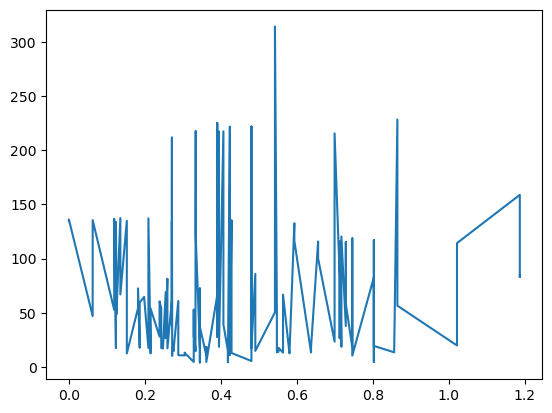

In [45]:
plt.plot(predictions_data_df["Utilization"], predictions_data_df["Actual App A Comm Time"])
plt.show()